

1. Подготовка выборки

2. Загрузка эмбеддингов

3. Проверка размерности

4. K-Means

5. Подбор количества кластеров

6. Silhouette Score

7. Размеры кластеров

8. Визуализация кластеров

9. HDBSCAN

10. Сравнение методов

11. Вывод

# Кластеризация эмбеддингов

Цель данного этапа — исследовать структуру векторных представлений товаров с помощью алгоритмов кластеризации.

В отличие от предварительной визуализации, выполненной в предыдущем ноутбуке, здесь необходимо использовать эмбеддинги, непосредственно связанные с товарами исходного датасета.

Для каждого объекта требуется сохранить соответствие между векторным представлением и его `category_id`. Это позволит не только обнаружить структуру кластеров, но и сравнить полученные группы с исходной категоризацией товаров.

In [3]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

DATA_PATH = "../data/raw/dataset-electronics-5M.parquet"

parquet_file = pq.ParquetFile(DATA_PATH)

print("Количество строк:", parquet_file.metadata.num_rows)
print("Количество row groups:", parquet_file.num_row_groups)
print("Колонки:", parquet_file.schema.names)

Количество строк: 4793821
Количество row groups: 2108
Колонки: ['category_id', 'embedding', 'model_id', 'model_text', 'path']


In [4]:
row_group = parquet_file.read_row_group(
    0,
    columns=["embedding", "category_id", "model_id"]
).to_pandas()

print(row_group.shape)
print(row_group.head())
print()
print("Тип embedding:", type(row_group["embedding"].iloc[0]))
print("Размер embedding:", len(row_group["embedding"].iloc[0]), "байт")

(3578, 3)
                                           embedding  category_id    model_id
0  b'[\x03\x00\x00\x00\x00\x00\x00\xb5\xbf;\x03\x...        91499  4513599754
1  b'[\x03\x00\x00\x00\x00\x00\x00\xa6\xbf;\x03\x...        91499  4513599755
2  b'[\x03\x00\x00\x00\x00\x00\x80\xb0\xbf;\x03\x...        91499  4513599756
3  b'[\x03\x00\x00\x00\x00\x00@\xca\xbf;\x03\x00\...        91499  4513599757
4  b"[\x03\x00\x00\x00\x00\x00@\xb3\xbf;\x03\x00\...        91499  4513599758

Тип embedding: <class 'bytes'>
Размер embedding: 3122 байт


In [5]:
import struct
import numpy as np

emb = row_group["embedding"].iloc[0]

print("Размер:", len(emb))
print("\nПервые 64 байта:")
print(emb[:64])

print("\nHEX:")
print(emb[:64].hex())

print("\nПервые 8 байт как uint64:")
print(struct.unpack("<Q", emb[:8]))

print("\nПервые 16 байт как float32:")
print(np.frombuffer(emb[:16], dtype="<f4"))

print("\nПервые 16 байт как float64:")
print(np.frombuffer(emb[:16], dtype="<f8"))

Размер: 3122

Первые 64 байта:
b'[\x03\x00\x00\x00\x00\x00\x00\xb5\xbf;\x03\x00\x00\x00\x00\x00`v\xbf;\x03\x00\x00\x00\x00\x00@\xb4\xbf;\x03\x00\x00\x00\x00\x00\xa0\x97?;\x03\x00\x00\x00\x00\x00\xc0}?;\x03\x00\x00\x00\x00\x00\xa0\xc3\xbf;\x03\x00\x00'

HEX:
5b03000000000000b5bf3b0300000000006076bf3b03000000000040b4bf3b030000000000a0973f3b030000000000c07d3f3b030000000000a0c3bf3b030000

Первые 8 байт как uint64:
(859,)

Первые 16 байт как float32:
[1.203715e-42 0.000000e+00 5.517443e-37 0.000000e+00]

Первые 16 байт как float64:
[4.24402390e-321 2.68017515e-316]


In [6]:
for i in range(5):
    emb = row_group["embedding"].iloc[i]
    
    print(
        i,
        "size =", len(emb),
        "first_16 =", emb[:16].hex()
    )

0 size = 3122 first_16 = 5b03000000000000b5bf3b0300000000
1 size = 3122 first_16 = 5b03000000000000a6bf3b0300000000
2 size = 3122 first_16 = 5b03000000000080b0bf3b0300000000
3 size = 3122 first_16 = 5b03000000000040cabf3b0300000000
4 size = 3122 first_16 = 5b03000000000040b3bf3b0300000000


In [7]:
import numpy as np


def decode_embedding(data):
    """
    Декодирует embedding из бинарного формата Parquet.

    Формат:
    2 байта marker + 312 раз:
    8 байт float64 + 2 байта marker
    """
    
    data = bytes(data)
    
    # 3122 = 2 + 312 * 10
    if len(data) != 3122:
        raise ValueError(f"Неожиданный размер embedding: {len(data)}")
    
    values = np.empty(312, dtype=np.float64)
    
    for i in range(312):
        start = 2 + i * 10
        values[i] = np.frombuffer(
            data[start:start + 8],
            dtype="<f8"
        )[0]
    
    return values.astype(np.float32)

In [8]:
emb = decode_embedding(row_group["embedding"].iloc[0])

print("Shape:", emb.shape)
print("Dtype:", emb.dtype)
print("First 10 values:", emb[:10])
print("Min:", emb.min())
print("Max:", emb.max())
print("Mean:", emb.mean())
print("Std:", emb.std())

Shape: (312,)
Dtype: float32
First 10 values: [-0.08203125 -0.00546265 -0.07910156  0.02307129  0.00726318 -0.15332031
 -0.02185059 -0.00970459  0.00848389 -0.04150391]
Min: -0.203125
Max: 0.16894531
Mean: 0.00020094406
Std: 0.056703072


In [9]:
X_test = np.vstack([
    decode_embedding(x)
    for x in row_group["embedding"]
])

print("Shape:", X_test.shape)
print("Dtype:", X_test.dtype)
print("Min:", X_test.min())
print("Max:", X_test.max())
print("Mean:", X_test.mean())
print("Std:", X_test.std())

Shape: (3578, 312)
Dtype: float32
Min: -0.28125
Max: 0.30078125
Mean: 0.00034120737
Std: 0.05661959


In [10]:
norms = np.linalg.norm(X_test, axis=1)

print("Norm min:", norms.min())
print("Norm max:", norms.max())
print("Norm mean:", norms.mean())
print("Norm median:", np.median(norms))
print("Zero vectors:", np.sum(norms < 1e-6))

Norm min: 0.9962701
Norm max: 1.0040885
Norm mean: 1.0001186
Norm median: 1.0001502
Zero vectors: 0


In [11]:
# Нормы всех векторов
norms = np.linalg.norm(X_test, axis=1)

print("Нормы:")
print("Min:", norms.min())
print("Max:", norms.max())
print("Mean:", norms.mean())
print("Median:", np.median(norms))

print("\nНулевые векторы:", np.sum(norms < 1e-6))

# Проверка NaN / Inf
print("\nNaN:", np.isnan(X_test).sum())
print("Inf:", np.isinf(X_test).sum())


Нормы:
Min: 0.9962701
Max: 1.0040885
Mean: 1.0001186
Median: 1.0001502

Нулевые векторы: 0

NaN: 0
Inf: 0


In [12]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(X_test[:100])

# Убираем диагональ
mask = ~np.eye(100, dtype=bool)

print("Средняя cosine similarity:", similarity[mask].mean())
print("Медиана:", np.median(similarity[mask]))
print("Min:", similarity[mask].min())
print("Max:", similarity[mask].max())

Средняя cosine similarity: 0.078651905
Медиана: 0.04448076
Min: -0.3814882
Max: 1.0


In [13]:
categories = row_group["category_id"].to_numpy()

unique_categories, counts = np.unique(
    categories,
    return_counts=True
)

print("Категории в row group:")
for category, count in zip(unique_categories, counts):
    print(category, "->", count)

Категории в row group:
91072 -> 903
91499 -> 895
2724669 -> 888
4976530 -> 892


In [14]:
target_category = unique_categories[np.argmax(counts)]

idx = np.where(categories == target_category)[0]

X_category = X_test[idx]

similarity_category = cosine_similarity(X_category[:100])

mask = ~np.eye(len(X_category[:100]), dtype=bool)

print("Категория:", target_category)
print("Количество товаров:", len(X_category))

print(
    "Средняя similarity:",
    similarity_category[mask].mean()
)

Категория: 91072
Количество товаров: 903
Средняя similarity: 0.47211948


In [15]:
SAMPLE_SIZE = 100_000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

total_rows = parquet_file.metadata.num_rows

sample_indices = np.sort(
    rng.choice(
        total_rows,
        size=SAMPLE_SIZE,
        replace=False
    )
)

print("Всего строк:", total_rows)
print("Размер выборки:", len(sample_indices))

Всего строк: 4793821
Размер выборки: 100000


In [16]:
X_list = []
y_list = []

collected = 0

for rg in range(parquet_file.num_row_groups):
    
    if collected >= SAMPLE_SIZE:
        break
    
    batch = parquet_file.read_row_group(
        rg,
        columns=["embedding", "category_id"]
    ).to_pandas()
    
    remaining = SAMPLE_SIZE - collected
    
    if len(batch) > remaining:
        batch = batch.iloc[:remaining]
    
    X_batch = np.vstack([
        decode_embedding(x)
        for x in batch["embedding"]
    ])
    
    y_batch = batch["category_id"].to_numpy()
    
    X_list.append(X_batch)
    y_list.append(y_batch)
    
    collected += len(batch)
    
    if rg % 100 == 0:
        print(
            f"row group: {rg}, "
            f"собрано: {collected:,}"
        )

X = np.vstack(X_list)
y = np.concatenate(y_list)

print("\nИтог:")
print("X:", X.shape)
print("y:", y.shape)

row group: 0, собрано: 3,578

Итог:
X: (100000, 312)
y: (100000,)


In [17]:
unique_categories, category_counts = np.unique(
    y,
    return_counts=True
)

print("Количество категорий:", len(unique_categories))
print("Минимальный размер категории:", category_counts.min())
print("Максимальный размер категории:", category_counts.max())
print("Медианный размер категории:", np.median(category_counts))

Количество категорий: 5
Минимальный размер категории: 6608
Максимальный размер категории: 31339
Медианный размер категории: 18660.0


In [18]:
top_idx = np.argsort(category_counts)[-10:][::-1]

for i in top_idx:
    print(
        f"category_id={unique_categories[i]}: "
        f"{category_counts[i]:,}"
    )

category_id=91072: 31,339
category_id=91499: 25,004
category_id=2724669: 18,660
category_id=90626: 18,389
category_id=4976530: 6,608


In [19]:
from sklearn.cluster import KMeans

k_values = [5, 10, 25, 50]

kmeans_results = {}

for k in k_values:
    print(f"\nK = {k}")
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    kmeans_results[k] = {
        "model": kmeans,
        "labels": labels
    }
    
    print("Готово")
    print("Размеры кластеров:")
    print(np.bincount(labels))


K = 5
Готово
Размеры кластеров:
[21522 25143  6024 19644 27667]

K = 10
Готово
Размеры кластеров:
[ 5292  9177 18522 15319 18035 12202  4870  6005  4925  5653]

K = 25
Готово
Размеры кластеров:
[3308 4971 6558 5043 4667 4357 5204 1985 2741 2692 2099 2483 6027 3366
 3831 1929 2532 3459 3371 5028 4579 8462 3248 1047 7013]

K = 50
Готово
Размеры кластеров:
[1962 2408 1312 1315 1595 1560 3194 3429 1911 2822 1774 2555 2499 1456
 2879  729 1168 3224 1430 2920 2693 3100 2676 1446 1469 1172 3824 1301
  987 1158 4425 2667  986 2680 2617 1165 1420 1999 1681  970 1849 2465
 2337 1380  985 3433 1980  840 1151 1002]


In [20]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

results = []

for k, result in kmeans_results.items():
    
    labels = result["labels"]
    
    # Silhouette на подвыборке,
    # чтобы не тратить слишком много памяти/времени
    rng = np.random.default_rng(RANDOM_STATE)
    
    silhouette_idx = rng.choice(
        len(X),
        size=min(20_000, len(X)),
        replace=False
    )
    
    silhouette = silhouette_score(
        X[silhouette_idx],
        labels[silhouette_idx],
        metric="cosine"
    )
    
    ari = adjusted_rand_score(y, labels)
    
    nmi = normalized_mutual_info_score(y, labels)
    
    results.append({
        "K": k,
        "Silhouette": silhouette,
        "ARI": ari,
        "NMI": nmi
    })

results_df = pd.DataFrame(results)

results_df

,K,Silhouette,ARI,NMI
0,5,0.139854,0.573517,0.672011
1,10,0.126361,0.486171,0.628402
2,25,0.078788,0.203683,0.504604
3,50,0.092042,0.119892,0.465088


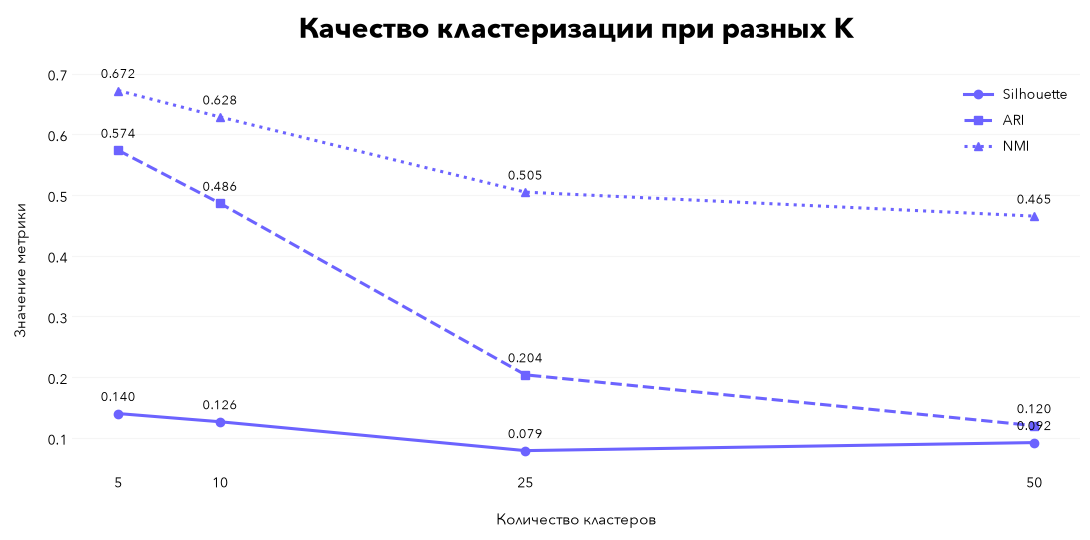

In [21]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Avenir Next"

ACCENT = "#6C63FF"

fig, ax = plt.subplots(figsize=(11, 5.5))

metrics = [
    ("Silhouette", "-", "o"),
    ("ARI", "--", "s"),
    ("NMI", ":", "^")
]

for metric, linestyle, marker in metrics:
    ax.plot(
        results_df["K"],
        results_df[metric],
        color=ACCENT,
        linestyle=linestyle,
        marker=marker,
        linewidth=2.2,
        markersize=6,
        label=metric
    )

    for _, row in results_df.iterrows():
        value = row[metric]

        ax.annotate(
            f"{value:.3f}",
            (row["K"], value),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

ax.set_title(
    "Качество кластеризации при разных K",
    fontsize=20,
    fontweight="bold",
    pad=25
)

ax.set_xlabel(
    "Количество кластеров",
    fontsize=11,
    labelpad=12
)

ax.set_ylabel(
    "Значение метрики",
    fontsize=11,
    labelpad=12
)

ax.set_xticks(results_df["K"])

ax.grid(
    axis="y",
    alpha=0.12,
    linewidth=0.8
)

ax.tick_params(
    axis="both",
    length=0,
    labelsize=10
)

ax.legend(
    frameon=False,
    loc="upper right"
)

# Убираем рамку полностью
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

Мы получили только 5 категорий, хотя во всей выборке EDA было 122 категории. Причина в том, что текущая загрузка берёт первые 100 000 товаров, а Parquet, судя по всему, организован неслучайно — первые row groups сильно сконцентрированы на нескольких категориях.

То есть сейчас это не репрезентативная случайная выборка.

Поэтому я бы не записывал пока K=5 как окончательный результат.

In [22]:
SAMPLE_SIZE = 100_000
RANDOM_STATE = 42

# Сначала читаем только category_id
category_data = parquet_file.read(
    columns=["category_id"]
).to_pandas()

print("Всего строк:", len(category_data))
print("Категорий:", category_data["category_id"].nunique())

Всего строк: 4793821
Категорий: 122


In [23]:
sample_fraction = SAMPLE_SIZE / len(category_data)

sample_indices = (
    category_data
    .groupby("category_id", group_keys=False)
    .sample(
        frac=sample_fraction,
        random_state=RANDOM_STATE
    )
    .index
)

sample_indices = np.sort(sample_indices.to_numpy())

print("Размер выборки:", len(sample_indices))

Размер выборки: 100001


In [24]:
sample_categories = category_data.iloc[sample_indices]["category_id"]

print(
    "Категорий в выборке:",
    sample_categories.nunique()
)

print(
    sample_categories.value_counts().describe()
)

Категорий в выборке: 120
count      120.000000
mean       833.341667
std       2310.124055
min          5.000000
25%         77.500000
50%        189.000000
75%        494.250000
max      21001.000000
Name: count, dtype: float64


In [25]:
sample_indices_set = set(sample_indices)

X_list = []
y_list = []

current_start = 0

for rg in range(parquet_file.num_row_groups):

    metadata = parquet_file.metadata.row_group(rg)
    num_rows = metadata.num_rows

    current_end = current_start + num_rows

    # Индексы выборки внутри текущего row group
    local_indices = [
        idx - current_start
        for idx in sample_indices
        if current_start <= idx < current_end
    ]

    if local_indices:

        batch = parquet_file.read_row_group(
            rg,
            columns=["embedding", "category_id"]
        ).to_pandas()

        selected = batch.iloc[local_indices]

        X_batch = np.vstack([
            decode_embedding(x)
            for x in selected["embedding"]
        ])

        y_batch = selected["category_id"].to_numpy()

        X_list.append(X_batch)
        y_list.append(y_batch)

    current_start = current_end

    if rg % 200 == 0:
        print(
            f"Обработано row groups: {rg}/{parquet_file.num_row_groups}"
        )

X = np.vstack(X_list)
y = np.concatenate(y_list)

print("\nИтог:")
print("X:", X.shape)
print("y:", y.shape)
print("Категорий:", len(np.unique(y)))

Обработано row groups: 0/2108
Обработано row groups: 200/2108
Обработано row groups: 400/2108
Обработано row groups: 600/2108
Обработано row groups: 800/2108
Обработано row groups: 1000/2108
Обработано row groups: 1200/2108
Обработано row groups: 1400/2108
Обработано row groups: 1600/2108
Обработано row groups: 1800/2108
Обработано row groups: 2000/2108

Итог:
X: (100001, 312)
y: (100001,)
Категорий: 120


In [26]:
from sklearn.cluster import KMeans

k_values = [5, 10, 25, 50, 100]

kmeans_results = {}

for k in k_values:
    print(f"\nK = {k}")
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    kmeans_results[k] = {
        "model": kmeans,
        "labels": labels
    }
    
    print("Готово")
    print("Размеры кластеров:")
    print(np.bincount(labels))


K = 5
Готово
Размеры кластеров:
[12407 20901 38343 11434 16916]

K = 10
Готово
Размеры кластеров:
[10777 11257  7079 10640 17526 15572 10996  5303  4912  5939]

K = 25
Готово
Размеры кластеров:
[3664 2358 3422 2950 5055 3203 2224 4141 2349 5370 3989 2509 4260 4334
 2381 9121  680 8211 3414 1399 6251 5273 3078 3228 7137]

K = 50
Готово
Размеры кластеров:
[1747 3299 2234 1483 1362 2015 2016 2058 2174 3331  876 2409 1829 2918
 2092 1897 1077  975 1553 4154 2322 1822 2133  663 1552 1625 3498 2989
 2399 1332 1042 1737 1522 3847 1471  686  933  642 1892 1913 3603 1089
 1807 2898 1338  741 1959 3667 4154 1226]

K = 100
Готово
Размеры кластеров:
[1080  940 1277  875  980 1077 1138  571  680 1328  524 1100  681 1906
  915 2846  698 1077 1212  676  817 1108 2443  894 1301  739  629  542
 1153  328  534  860 1391 1907  412  750  626  585 1314  801 1462  701
  382  785 1386  670 1516  978 1274  542  847 1223  855  565  986  964
  588 1222 1269  766  456  856 1092  590  508  818  376  256 1718  99

In [27]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

results = []

for k, result in kmeans_results.items():
    
    labels = result["labels"]
    
    # Silhouette на подвыборке,
    # чтобы не тратить слишком много памяти/времени
    rng = np.random.default_rng(RANDOM_STATE)
    
    silhouette_idx = rng.choice(
        len(X),
        size=min(20_000, len(X)),
        replace=False
    )
    
    silhouette = silhouette_score(
        X[silhouette_idx],
        labels[silhouette_idx],
        metric="cosine"
    )
    
    ari = adjusted_rand_score(y, labels)
    
    nmi = normalized_mutual_info_score(y, labels)
    
    results.append({
        "K": k,
        "Silhouette": silhouette,
        "ARI": ari,
        "NMI": nmi
    })

results_df = pd.DataFrame(results)

results_df

,K,Silhouette,ARI,NMI
0,5,0.081965,0.222305,0.407632
1,10,0.090693,0.397844,0.500515
2,25,0.069059,0.318180,0.543690
3,50,0.079145,0.237482,0.553958
4,100,0.076553,0.143989,0.514495


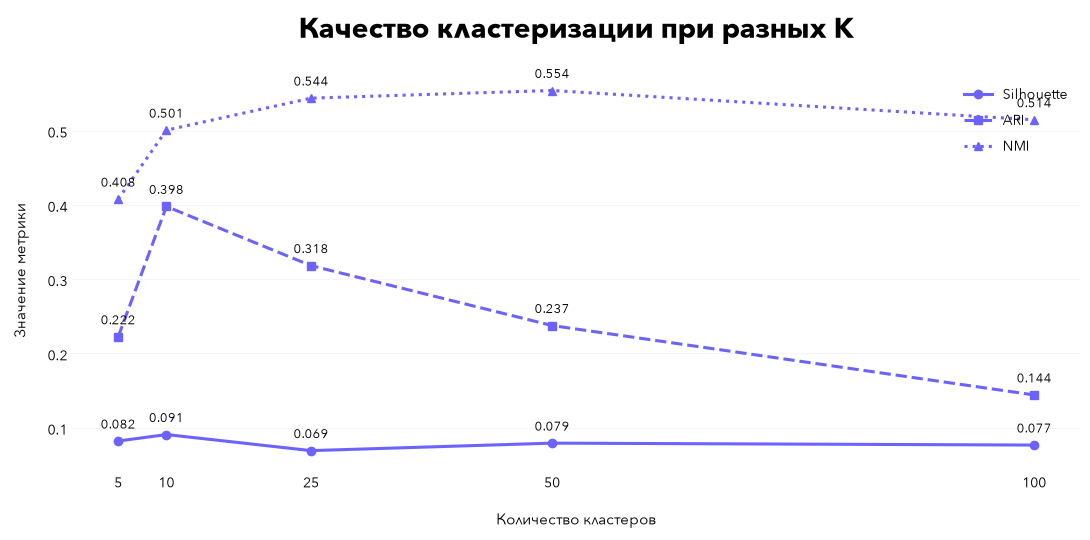

In [28]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Avenir Next"

ACCENT = "#6C63FF"

fig, ax = plt.subplots(figsize=(11, 5.5))

metrics = [
    ("Silhouette", "-", "o"),
    ("ARI", "--", "s"),
    ("NMI", ":", "^")
]

for metric, linestyle, marker in metrics:
    ax.plot(
        results_df["K"],
        results_df[metric],
        color=ACCENT,
        linestyle=linestyle,
        marker=marker,
        linewidth=2.2,
        markersize=6,
        label=metric
    )

    for _, row in results_df.iterrows():
        value = row[metric]

        ax.annotate(
            f"{value:.3f}",
            (row["K"], value),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

ax.set_title(
    "Качество кластеризации при разных K",
    fontsize=20,
    fontweight="bold",
    pad=25
)

ax.set_xlabel(
    "Количество кластеров",
    fontsize=11,
    labelpad=12
)

ax.set_ylabel(
    "Значение метрики",
    fontsize=11,
    labelpad=12
)

ax.set_xticks(results_df["K"])

ax.grid(
    axis="y",
    alpha=0.12,
    linewidth=0.8
)

ax.tick_params(
    axis="both",
    length=0,
    labelsize=10
)

ax.legend(
    frameon=False,
    loc="upper right"
)

# Убираем рамку полностью
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [29]:
k_values_detailed = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100]

results_detailed = []

rng = np.random.default_rng(42)

# Одна и та же подвыборка для Silhouette,
# чтобы сравнение K было честным
silhouette_idx = rng.choice(
    len(X),
    size=min(20_000, len(X)),
    replace=False
)

for k in k_values_detailed:

    print(f"K = {k}")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    silhouette = silhouette_score(
        X[silhouette_idx],
        labels[silhouette_idx],
        metric="cosine"
    )

    ari = adjusted_rand_score(y, labels)
    nmi = normalized_mutual_info_score(y, labels)

    results_detailed.append({
        "K": k,
        "Silhouette": silhouette,
        "ARI": ari,
        "NMI": nmi
    })

results_detailed_df = pd.DataFrame(results_detailed)

results_detailed_df

K = 5
K = 10
K = 15
K = 20
K = 25
K = 30
K = 40
K = 50
K = 75
K = 100


,K,Silhouette,ARI,NMI
0,5,0.081965,0.222305,0.407632
1,10,0.090693,0.397844,0.500515
2,15,0.078485,0.389127,0.538835
3,20,0.072919,0.357157,0.540776
4,25,0.069059,0.318180,0.543690
5,30,0.070842,0.283402,0.534236
6,40,0.074140,0.245716,0.530457
7,50,0.079145,0.237482,0.553958
8,75,0.075774,0.177179,0.539649
9,100,0.076553,0.143989,0.514495


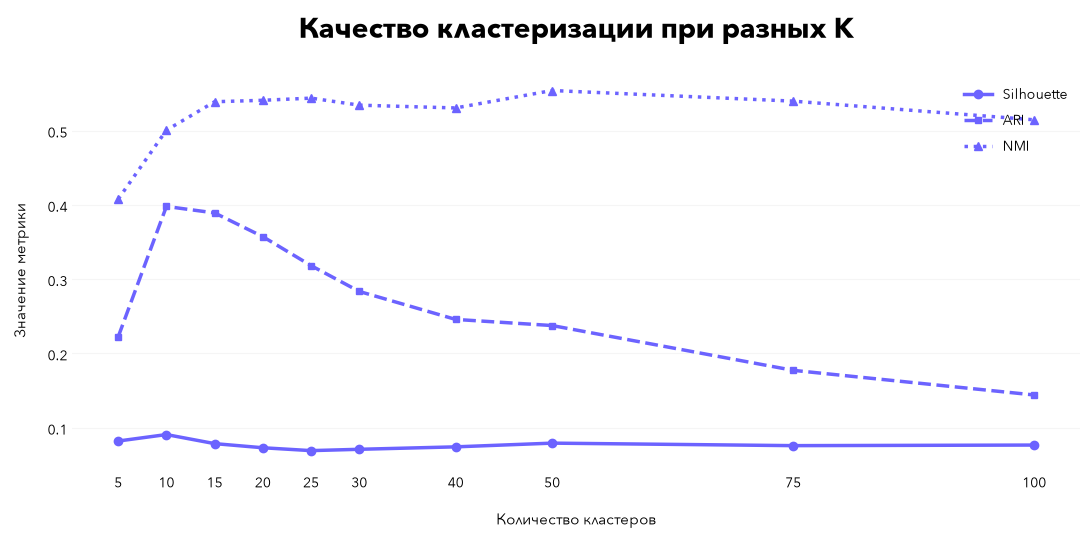

In [30]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Avenir Next"

ACCENT = "#6C63FF"

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(
    results_detailed_df["K"],
    results_detailed_df["Silhouette"],
    color=ACCENT,
    linewidth=2.5,
    marker="o",
    markersize=6,
    label="Silhouette"
)

ax.plot(
    results_detailed_df["K"],
    results_detailed_df["ARI"],
    color=ACCENT,
    linewidth=2.5,
    linestyle="--",
    marker="s",
    markersize=5,
    label="ARI"
)

ax.plot(
    results_detailed_df["K"],
    results_detailed_df["NMI"],
    color=ACCENT,
    linewidth=2.5,
    linestyle=":",
    marker="^",
    markersize=6,
    label="NMI"
)

ax.set_title(
    "Качество кластеризации при разных K",
    fontsize=20,
    fontweight="bold",
    pad=25
)

ax.set_xlabel(
    "Количество кластеров",
    fontsize=11,
    labelpad=12
)

ax.set_ylabel(
    "Значение метрики",
    fontsize=11,
    labelpad=12
)

ax.set_xticks(k_values_detailed)

ax.grid(
    axis="y",
    alpha=0.12,
    linewidth=0.8
)

ax.tick_params(
    axis="both",
    length=0,
    labelsize=10
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(
    frameon=False,
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [31]:
best_silhouette = results_detailed_df.loc[
    results_detailed_df["Silhouette"].idxmax()
]

best_ari = results_detailed_df.loc[
    results_detailed_df["ARI"].idxmax()
]

best_nmi = results_detailed_df.loc[
    results_detailed_df["NMI"].idxmax()
]

print("Лучший Silhouette:")
print(best_silhouette)

print("\nЛучший ARI:")
print(best_ari)

print("\nЛучший NMI:")
print(best_nmi)

Лучший Silhouette:
K             10.000000
Silhouette     0.090693
ARI            0.397844
NMI            0.500515
Name: 1, dtype: float64

Лучший ARI:
K             10.000000
Silhouette     0.090693
ARI            0.397844
NMI            0.500515
Name: 1, dtype: float64

Лучший NMI:
K             50.000000
Silhouette     0.079145
ARI            0.237482
NMI            0.553958
Name: 7, dtype: float64


Вывод по подробному эксперименту K-Means

На стратифицированной выборке из 100 000 товаров были исследованы значения числа кластеров K от 5 до 100. Качество кластеризации оценивалось по трём метрикам: Silhouette Score, ARI и NMI.

Основной результат — K = 10 является наиболее сбалансированным вариантом:

* Silhouette = 0.091 — максимальное значение среди всех рассмотренных K;
* ARI = 0.398 — также максимальное значение;
* NMI = 0.501 — немного ниже максимального значения, полученного при K = 50 (0.554).

При увеличении числа кластеров после K = 10 наблюдается общее снижение ARI:
K=10 → 0.398

K=15 → 0.389

K=20 → 0.357

K=25 → 0.318

K=30 → 0.283

K=50 → 0.237

K=100 → 0.144

Это означает, что увеличение количества кластеров приводит к более мелкому разбиению embedding-пространства, но полученные кластеры всё хуже соответствуют исходным категориям товаров.

При этом NMI ведёт себя иначе: его максимальное значение достигается при K = 50:

K=10 → NMI 0.501

K=25 → NMI 0.544

K=50 → NMI 0.554

Это показывает, что при большем количестве кластеров сохраняется больше информации об исходных категориях, однако эта информация распределяется между большим количеством небольших кластеров. Поэтому высокий NMI при K=50 не означает, что K=50 является лучшим вариантом по совокупности критериев.

HDBSCAN

In [32]:
!pip install hdbscan

/Users/denis/Desktop/coursework/Course_work_community_detection/.venv/bin/pip: line 2: /Users/denis/Desktop/Курсовая работе/Course_work_community_detection/.venv/bin/python3.13: No such file or directory
/Users/denis/Desktop/coursework/Course_work_community_detection/.venv/bin/pip: line 2: exec: /Users/denis/Desktop/Курсовая работе/Course_work_community_detection/.venv/bin/python3.13: cannot execute: No such file or directory


In [33]:
import hdbscan
import numpy as np
import pandas as pd

from sklearn.preprocessing import normalize
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

In [34]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import normalize
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

HDBSCAN_SIZE = 50_000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

hdb_idx = rng.choice(
    len(X),
    size=HDBSCAN_SIZE,
    replace=False
)

X_hdb = X[hdb_idx]
y_hdb = y[hdb_idx]

print("X_hdb:", X_hdb.shape)
print("y_hdb:", y_hdb.shape)
print("Категорий:", len(np.unique(y_hdb)))

X_hdb: (50000, 312)
y_hdb: (50000,)
Категорий: 120


In [35]:
X_hdb_norm = normalize(X_hdb, norm="l2")

print("Shape:", X_hdb_norm.shape)
print("Norm первого вектора:", np.linalg.norm(X_hdb_norm[0]))

Shape: (50000, 312)
Norm первого вектора: 1.0


In [36]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)

hdb_labels = clusterer.fit_predict(X_hdb_norm)

print("Кластеризация завершена")

Кластеризация завершена


In [37]:
unique_labels, counts = np.unique(
    hdb_labels,
    return_counts=True
)

n_clusters = np.sum(unique_labels != -1)
n_noise = np.sum(hdb_labels == -1)
noise_pct = n_noise / len(hdb_labels) * 100

print("Количество кластеров:", n_clusters)
print("Объектов:", len(hdb_labels))
print("Шум:", n_noise)
print(f"Доля шума: {noise_pct:.2f}%")

Количество кластеров: 22
Объектов: 50000
Шум: 43786
Доля шума: 87.57%


In [38]:
cluster_sizes = (
    pd.Series(hdb_labels)
    .value_counts()
    .sort_index()
)

print(cluster_sizes)

-1     43786
 0       266
 1       113
 2       105
 3       247
 4       310
 5       191
 6       194
 7       152
 8       135
 9       233
 10      532
 11      110
 12      245
 13      919
 14      693
 15      103
 16      347
 17      278
 18      174
 19      372
 20      225
 21      270
Name: count, dtype: int64


In [39]:
cluster_sizes_no_noise = (
    pd.Series(hdb_labels[hdb_labels != -1])
    .value_counts()
    .sort_values(ascending=False)
)

print(cluster_sizes_no_noise)

13    919
14    693
10    532
19    372
16    347
4     310
17    278
21    270
0     266
3     247
12    245
9     233
20    225
6     194
5     191
18    174
7     152
8     135
1     113
11    110
2     105
15    103
Name: count, dtype: int64
